
Training RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
RNN Results:
Training Time: 2.43 sec
MSE: 0.0001

Training LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
LSTM Results:
Training Time: 2.06 sec
MSE: 0.0001

Training GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
GRU Results:
Training Time: 2.49 sec
MSE: 0.0001


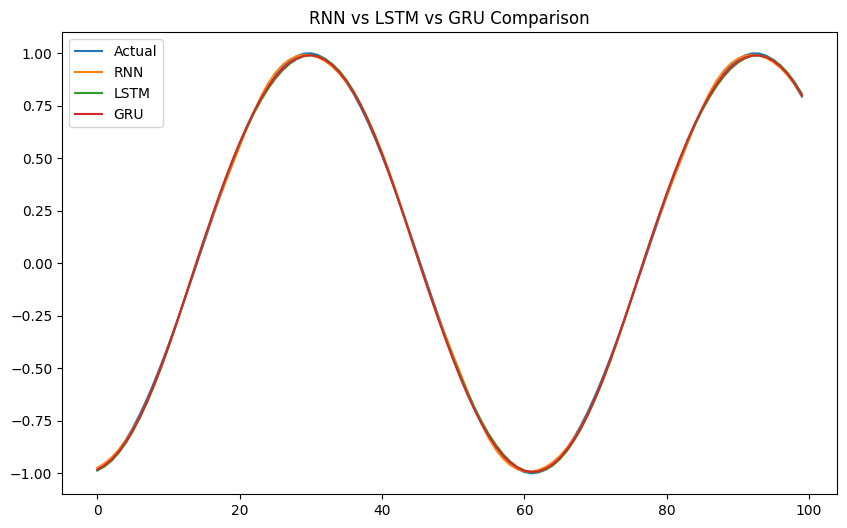

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from sklearn.metrics import mean_squared_error

# 1. Generate Dataset (Sine Wave)
def create_data(seq_length=10):
    x = np.linspace(0, 100, 1000)
    y = np.sin(x)

    X = []
    Y = []

    for i in range(len(y) - seq_length):
        X.append(y[i:i+seq_length])
        Y.append(y[i+seq_length])

    X = np.array(X)
    Y = np.array(Y)

    return X, Y

# Load Data
seq_length = 10
X, Y = create_data(seq_length)

# Reshape for RNN input [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train-Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# 2. Model Builder
def build_model(model_type):
    model = Sequential()

    if model_type == "RNN":
        model.add(SimpleRNN(32, input_shape=(seq_length, 1)))
    elif model_type == "LSTM":
        model.add(LSTM(32, input_shape=(seq_length, 1)))
    elif model_type == "GRU":
        model.add(GRU(32, input_shape=(seq_length, 1)))

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    return model

# 3. Train & Evaluate Function
def train_and_evaluate(model_type):
    print(f"\nTraining {model_type}...")

    model = build_model(model_type)

    start_time = time.time()

    history = model.fit(
        X_train, Y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    training_time = time.time() - start_time

    predictions = model.predict(X_test)
    mse = mean_squared_error(Y_test, predictions)

    print(f"{model_type} Results:")
    print(f"Training Time: {training_time:.2f} sec")
    print(f"MSE: {mse:.4f}")

    return history, predictions, training_time, mse

# 4. Run All Models
results = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    history, preds, t, mse = train_and_evaluate(model_type)
    results[model_type] = (history, preds, t, mse)

# 5. Plot Results
plt.figure(figsize=(10,6))
plt.plot(Y_test[:100], label='Actual')

for model_type in results:
    plt.plot(results[model_type][1][:100], label=model_type)

plt.legend()
plt.title("RNN vs LSTM vs GRU Comparison")
plt.show()